In [1]:
from roctet import calc_roctet
from roctet.utils import auroc
from numpy import arange
import polars as pl
import polars.selectors as cs
import polars_ds as pds
from plotnine import (ggplot, aes, geom_line, geom_abline, labs, theme_set, theme_bw, theme)

In [2]:
theme_set(theme_bw())

## Data Generation

In [3]:
# generate datasets
dfs = calc_roctet(0.82, method="beta", n_sets = 10) # 0.82, 0.67
dfs[0].glimpse()

NameError: name 'dfs_sb' is not defined

In [ ]:
# consolidate to one dataset
df = pl.concat( [d.with_columns(index = i) for i,d in enumerate(dfs)] )

## ROC Summary

In [ ]:
# compare AUC values
aucs = [ auroc(d['target'].to_numpy(), d['score'].to_numpy()) for d in dfs]
print(aucs)
print(f"Max Diff: {max(aucs) - min(aucs)}")

[0.8185, 0.8196, 0.8202, 0.8194, 0.8188, 0.819, 0.8192, 0.8171, 0.8176, 0.8193]
Max Diff: 0.0030999999999999917


## ROC Curves

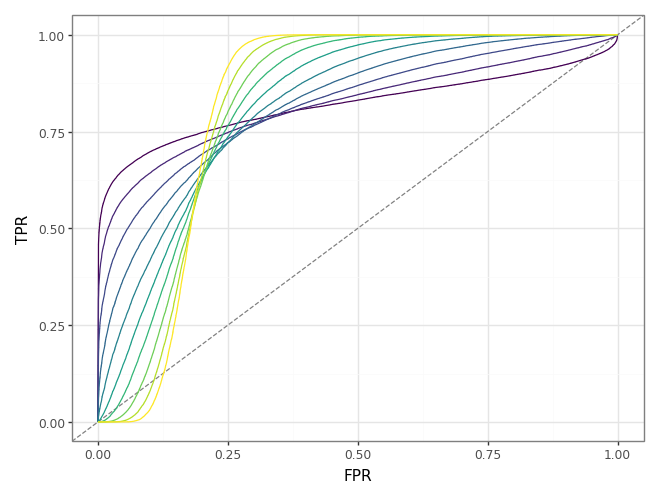

In [ ]:
# compute and display roc curve
df_roc = (
    df
    .sort('score', descending=True)
    .with_columns(
        neg_target = 1 - pl.col('target'),
        neg_target_ttl = (1 - pl.col('target')).sum().over('index'),
        pos_target = pl.col('target'),
        pos_target_ttl = pl.col('target').sum().over('index')
        )
    .with_columns(
        cum_fpr = pl.col('neg_target').cum_sum().over('index') / pl.col('neg_target_ttl'),
        cum_tpr = pl.col('pos_target').cum_sum().over('index') / pl.col('pos_target_ttl'),
    )
)

p = ggplot(df_roc)
p += aes(x = 'cum_fpr', y = 'cum_tpr', color = 'index', group = 'index')
p += geom_abline(intercept = 0, slope = 1, color = 'grey', linetype = 'dashed')
p += geom_line()
p += theme(legend_position='none')
p += labs(x = 'FPR', y = 'TPR')
p
# p.save('aucs.png')

## Metrics

In [ ]:
df_metrics = (
    df
    .group_by('index')
    .agg(metrics = pds.query_binary_metrics('target','score',0.5)).unnest('metrics')
)
df_metrics

index,precision,recall,f,avg_precision,roc_auc
i32,f64,f64,f64,f64,f64
0,0.627073,0.830806,0.714704,0.878415,0.818474
1,0.629036,0.845027,0.721207,0.8651,0.819642
2,0.634483,0.868795,0.733378,0.846213,0.820199
3,0.642622,0.901489,0.750356,0.818904,0.819368
4,0.651853,0.939621,0.76972,0.783093,0.81876
5,0.66085,0.973632,0.787313,0.741395,0.819029
6,0.665086,0.993239,0.796695,0.708816,0.819244
7,0.664973,0.999158,0.79851,0.685993,0.817124
8,0.666676,1.0,0.800006,0.676538,0.817575


In [ ]:
(
    df_metrics
    .drop('index')
    .select( 
        cs.all().std().name.prefix("std__"),
        (cs.all().max() - cs.all().min()).name.prefix("rng__")
    )
    .unpivot()
    .with_columns( pl.col('variable').str.split_exact("__",1) )
    .unnest("variable")
    .pivot(index='field_1',on='field_0')
)

field_1,std,rng
str,f64,f64
"""precision""",0.016285,0.039794
"""recall""",0.068255,0.169194
"""f""",0.034515,0.08544
"""avg_precision""",0.080991,0.206228
"""roc_auc""",0.000932,0.003075


## Lift Charts

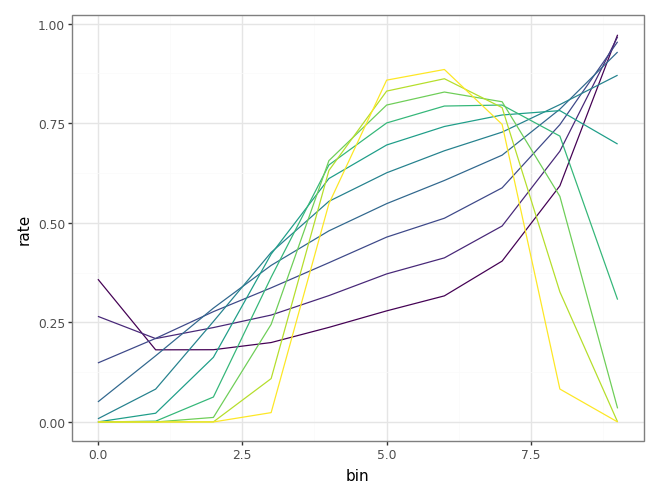

In [ ]:
# visualize lift curves
df = pl.concat( [d.with_columns(index = i) for i,d in enumerate(dfs)] )
df_lift = (
    df
    .group_by( 'index', 
               bin = pl.col('score').qcut(10, labels = arange(10).astype(str)).cast(pl.String).cast(pl.Int16) 
             )
    .agg( rate = pl.col('target').mean() )
)
p = ggplot(df_lift)
p += aes(x = 'bin', y = 'rate', color = 'index', group = 'index')
p += geom_line()
p